### UTS Model Deployment
### Alexandro Theo - 2802428633 - Dataset A

**Video Presentasi:** 


In [2]:
# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Regression models
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Metrics
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                              f1_score, roc_auc_score,
                              mean_squared_error, mean_absolute_error, r2_score)

import pickle
import os


### 2. Data Loading & Initial Inspection

In [3]:
# Load features and targets
df_features = pd.read_csv('A.csv')
df_targets = pd.read_csv('A_targets.csv')

# Merge on Student_ID
df = df_features.merge(df_targets, on='Student_ID')

print(f"Dataset shape: {df.shape}")
print(f"Features shape: {df_features.shape}")
print(f"Targets shape: {df_targets.shape}")
df.head()


Dataset shape: (5000, 25)
Features shape: (5000, 23)
Targets shape: (5000, 3)


,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,placement_status,salary_lpa
0,1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,...,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium,Placed,14.95
1,2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,...,1,7.1,8,Yes,Medium,Tier 3,Yes,Low,Placed,14.91
2,3,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,...,3,6.1,2,No,Low,Tier 2,Yes,High,Placed,17.73
3,4,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,...,2,7.3,7,No,Medium,Tier 1,Yes,Low,Placed,14.52
4,5,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,...,1,6.0,7,No,Medium,Tier 1,Yes,Medium,Placed,15.91


In [4]:
# Basic info
print("Dataset Info")
df.info()

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Student_ID                   5000 non-null   int64  
 1   gender                       5000 non-null   object 
 2   branch                       5000 non-null   object 
 3   cgpa                         5000 non-null   float64
 4   tenth_percentage             5000 non-null   float64
 5   twelfth_percentage           5000 non-null   float64
 6   backlogs                     5000 non-null   int64  
 7   study_hours_per_day          5000 non-null   float64
 8   attendance_percentage        5000 non-null   float64
 9   projects_completed           5000 non-null   int64  
 10  internships_completed        5000 non-null   int64  
 11  coding_skill_rating          5000 non-null   int64  
 12  communication_skill_rating   5000 non-null   int64  
 13  aptit

In [5]:
print("Statistical Summary")
df.describe().round(2)

Statistical Summary


,Student_ID,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,coding_skill_rating,communication_skill_rating,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level,salary_lpa
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.0,5000.00,5000.00,5000.00,5000.00
mean,2500.50,8.28,74.54,74.54,0.34,4.04,72.04,5.53,2.13,3.73,3.03,4.12,3.7,2.84,6.96,6.02,13.90
std,1443.52,1.01,10.27,10.24,0.61,1.97,7.72,2.05,1.14,1.28,1.41,0.72,1.6,1.78,1.15,2.85,6.25
min,1.00,5.00,50.00,50.00,0.00,0.00,44.70,0.00,0.00,1.00,1.00,1.00,0.0,0.00,4.00,1.00,0.00
25%,1250.75,7.61,67.40,67.60,0.00,2.70,66.60,4.00,1.00,3.00,2.00,4.00,3.0,2.00,6.20,4.00,12.51
50%,2500.50,8.32,74.70,74.80,0.00,4.00,72.05,6.00,2.00,4.00,3.00,4.00,4.0,3.00,7.00,6.00,15.76
75%,3750.25,9.02,82.00,81.70,1.00,5.40,77.20,7.00,3.00,5.00,4.00,5.00,5.0,4.00,7.80,9.00,18.33
max,5000.00,10.00,100.00,100.00,5.00,10.00,99.20,8.00,4.00,5.00,5.00,5.00,6.0,9.00,9.00,10.00,20.00


### 3. Exploratory Data Analysis (EDA)

### 3.1 Missing Values Analysis
Penanganan missing values penting untuk memastikan model tidak dilatih dengan data yang tidak lengkap.


In [6]:
# Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print("Kolom dengan missing values:")
print(missing_df)

Kolom dengan missing values:
                             Missing Count  Missing %
extracurricular_involvement           1006      20.12


### 3.2 Target Variable Distribution
Analisis distribusi target untuk memahami class imbalance pada klasifikasi dan distribusi nilai pada regresi.


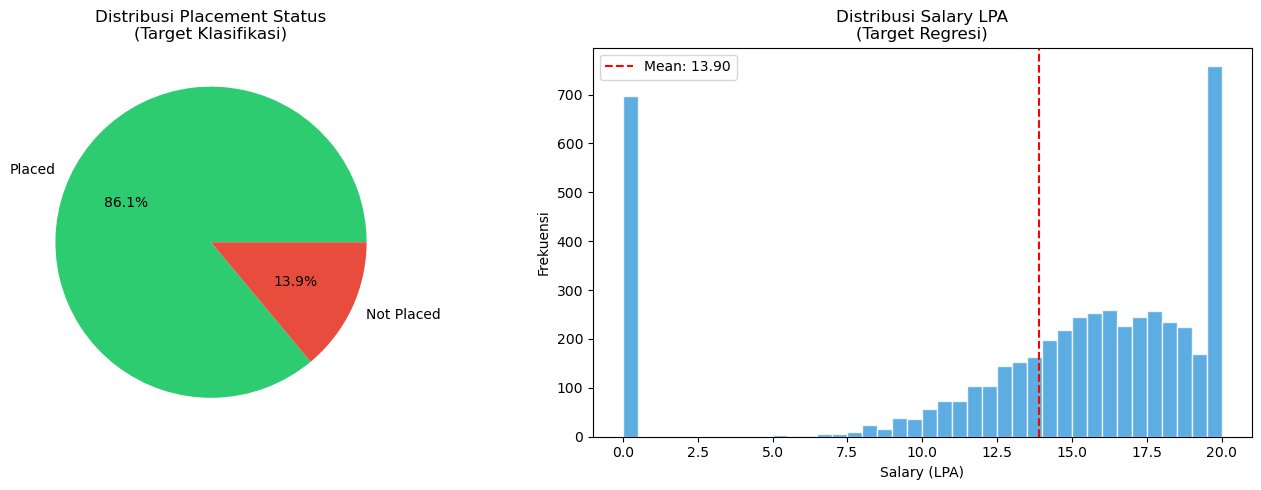

Placement Status Distribution:
placement_status
Placed        4303
Not Placed     697

Salary Stats: Mean=13.90, Std=6.25
Class Imbalance Ratio: 6.17:1


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Classification target
placement_counts = df['placement_status'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(placement_counts, labels=placement_counts.index, autopct='%1.1f%%', colors=colors)
axes[0].set_title('Distribusi Placement Status\n(Target Klasifikasi)')

# Regression target
axes[1].hist(df['salary_lpa'], bins=40, color='#3498db', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribusi Salary LPA\n(Target Regresi)')
axes[1].set_xlabel('Salary (LPA)')
axes[1].set_ylabel('Frekuensi')
axes[1].axvline(df['salary_lpa'].mean(), color='red', linestyle='--', label=f'Mean: {df["salary_lpa"].mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Placement Status Distribution:\n{placement_counts.to_string()}")
print(f"\nSalary Stats: Mean={df['salary_lpa'].mean():.2f}, Std={df['salary_lpa'].std():.2f}")
print(f"Class Imbalance Ratio: {placement_counts[0]/placement_counts[1]:.2f}:1")


### 3.3 Correlation Analysis
Analisis korelasi membantu mengidentifikasi fitur yang paling berpengaruh terhadap target variabel.


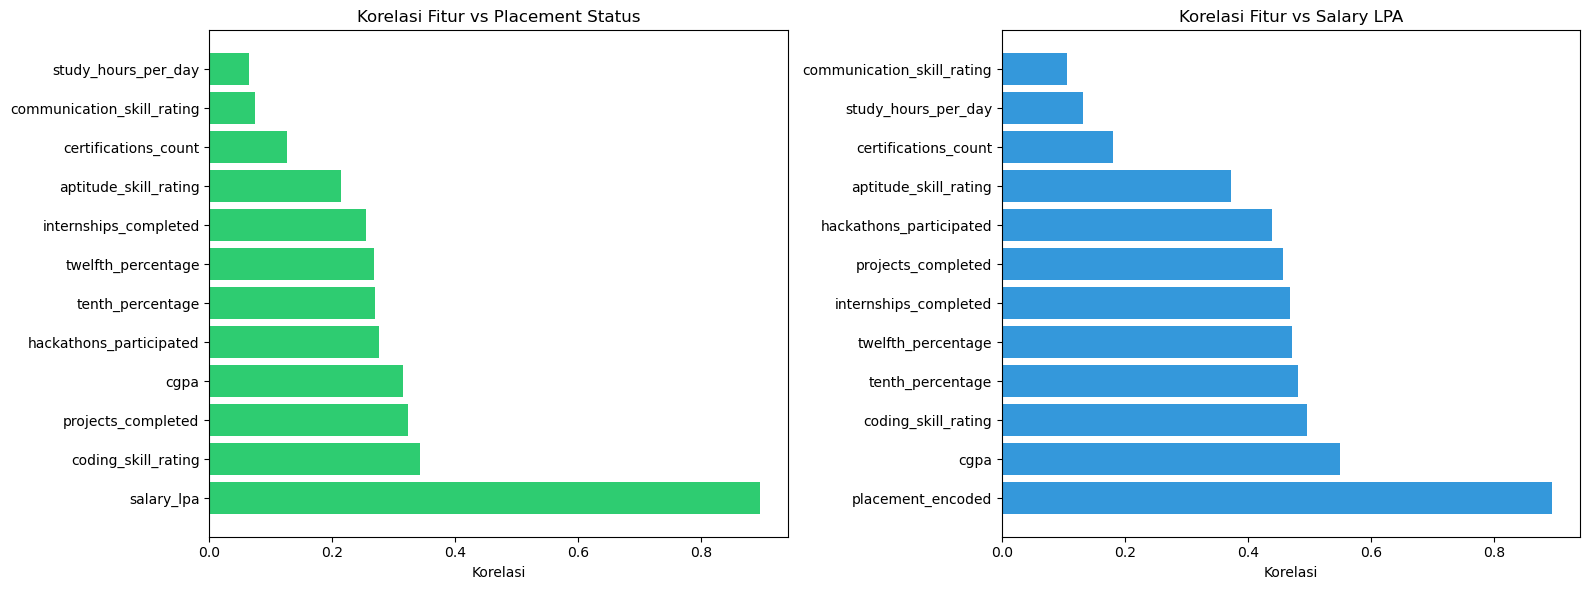

In [8]:
# Encode target for correlation
df_corr = df.copy()
df_corr['placement_encoded'] = (df_corr['placement_status'] == 'Placed').astype(int)

# Select numeric columns
numeric_cols = df_corr.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['Student_ID']]

# Correlation with targets
corr_placement = df_corr[numeric_cols].corr()['placement_encoded'].sort_values(ascending=False)
corr_salary = df_corr[numeric_cols].corr()['salary_lpa'].sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Placement correlation
corr_p = corr_placement.drop(['placement_encoded']).head(12)
colors_p = ['#2ecc71' if x > 0 else '#e74c3c' for x in corr_p]
axes[0].barh(corr_p.index, corr_p.values, color=colors_p)
axes[0].set_title('Korelasi Fitur vs Placement Status')
axes[0].set_xlabel('Korelasi')
axes[0].axvline(0, color='black', linewidth=0.5)

# Salary correlation
corr_s = corr_salary.drop(['salary_lpa']).head(12)
colors_s = ['#3498db' if x > 0 else '#e74c3c' for x in corr_s]
axes[1].barh(corr_s.index, corr_s.values, color=colors_s)
axes[1].set_title('Korelasi Fitur vs Salary LPA')
axes[1].set_xlabel('Korelasi')
axes[1].axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()


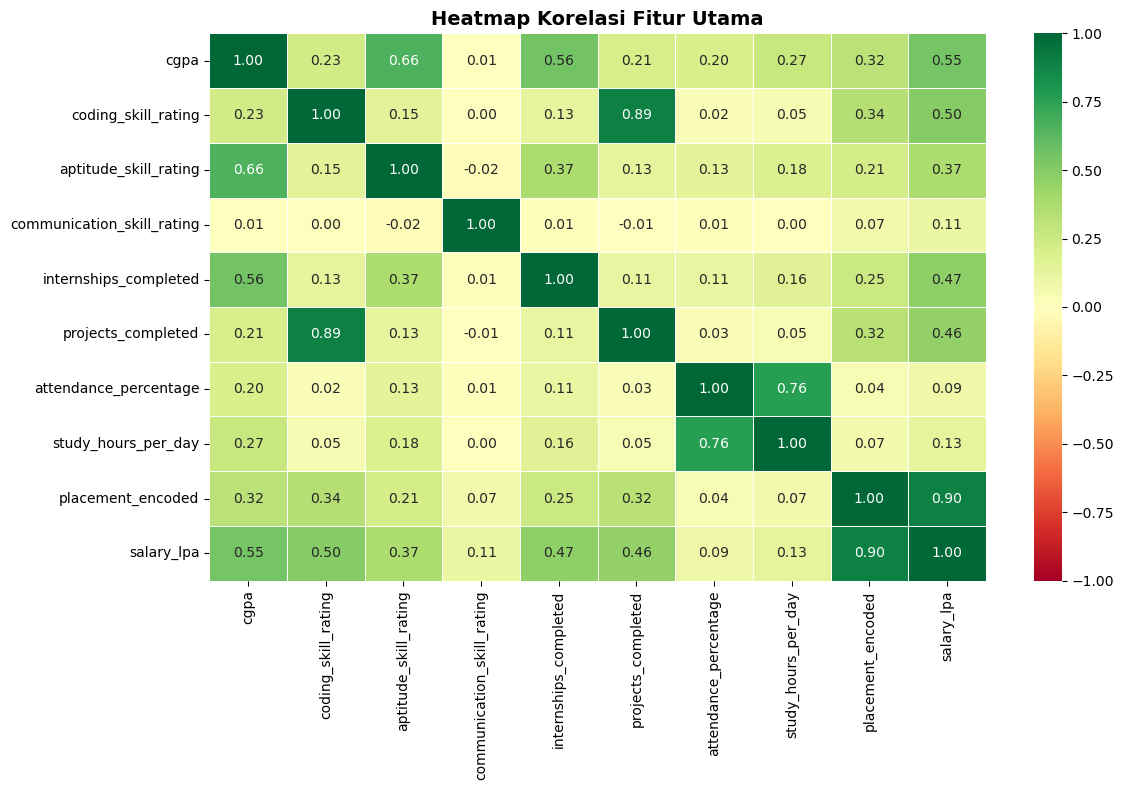

In [9]:
# Heatmap korelasi antar fitur numerik utama
key_features = ['cgpa', 'coding_skill_rating', 'aptitude_skill_rating', 
                'communication_skill_rating', 'internships_completed',
                'projects_completed', 'attendance_percentage', 
                'study_hours_per_day', 'placement_encoded', 'salary_lpa']

fig, ax = plt.subplots(figsize=(12, 8))
corr_matrix = df_corr[key_features].corr()
mask = np.triu(np.ones_like(corr_matrix), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', 
            center=0, ax=ax, vmin=-1, vmax=1, linewidths=0.5)
ax.set_title('Heatmap Korelasi Fitur Utama', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.4 Feature Distribution Analysis

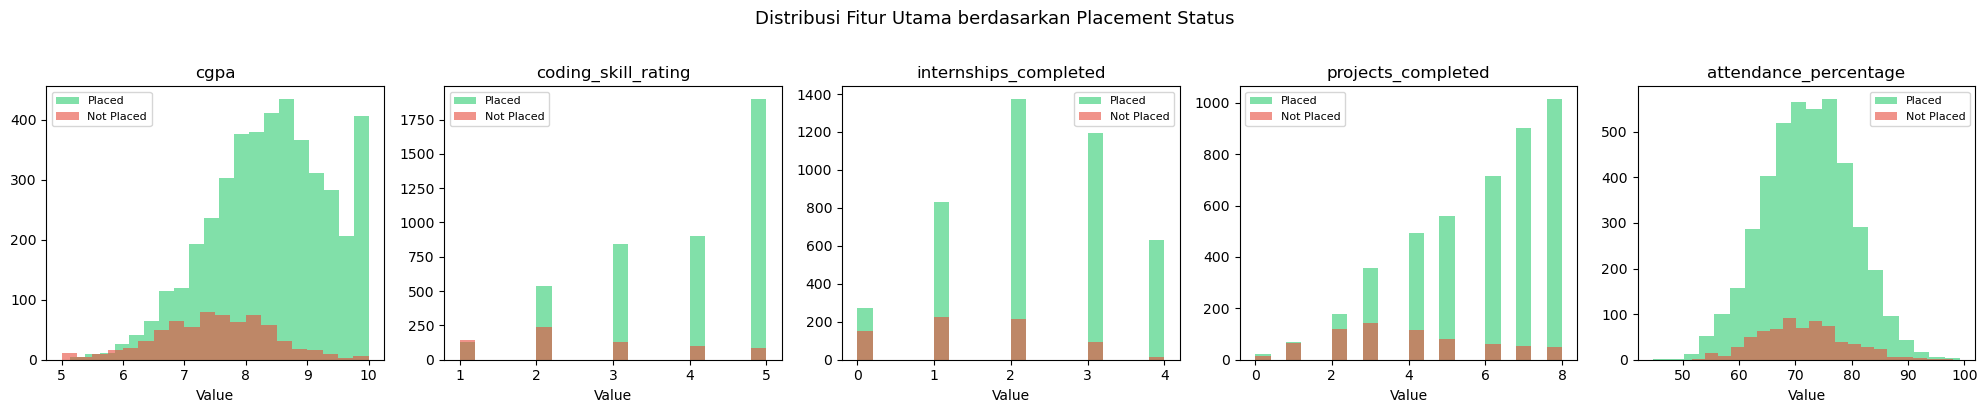

In [10]:
# Distribution of key features by placement status
key_features_dist = ['cgpa', 'coding_skill_rating', 'internships_completed', 
                     'projects_completed', 'attendance_percentage']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, feat in enumerate(key_features_dist):
    placed = df[df['placement_status']=='Placed'][feat]
    not_placed = df[df['placement_status']=='Not Placed'][feat]
    axes[i].hist(placed, alpha=0.6, bins=20, color='#2ecc71', label='Placed')
    axes[i].hist(not_placed, alpha=0.6, bins=20, color='#e74c3c', label='Not Placed')
    axes[i].set_title(feat)
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('Value')
plt.suptitle('Distribusi Fitur Utama berdasarkan Placement Status', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


## ⚙️ 4. Feature Engineering

Feature engineering dilakukan untuk menciptakan fitur baru yang lebih representatif dari data yang ada.
Alasan pemilihan fitur engineering:
1. **skill_composite**: Kombinasi skill rating (coding, communication, aptitude) mencerminkan kemampuan holistik mahasiswa
2. **academic_score**: Agregasi performa akademik (CGPA, kehadiran, jam belajar) sebagai indikator kesiapan kerja
3. **experience_score**: Kombinasi internship & proyek sebagai proxy pengalaman praktis


In [11]:
# Feature Engineering
df_eng = df.copy()

# 1. Composite skill score (skill holistik)
df_eng['skill_composite'] = (df_eng['coding_skill_rating'] + 
                              df_eng['communication_skill_rating'] + 
                              df_eng['aptitude_skill_rating']) / 3

# 2. Academic performance score
df_eng['academic_score'] = (df_eng['cgpa'] * 0.4 + 
                             df_eng['attendance_percentage'] / 100 * 10 * 0.3 +
                             df_eng['study_hours_per_day'] * 0.3)

# 3. Experience score  
df_eng['experience_score'] = (df_eng['internships_completed'] * 2 + 
                               df_eng['projects_completed'] + 
                               df_eng['certifications_count'] + 
                               df_eng['hackathons_participated'])

# 4. Lifestyle balance (sleep quality indicator)
df_eng['healthy_sleep'] = ((df_eng['sleep_hours'] >= 6) & (df_eng['sleep_hours'] <= 9)).astype(int)

# 5. High achiever flag
df_eng['high_achiever'] = ((df_eng['cgpa'] >= 8.0) & 
                            (df_eng['coding_skill_rating'] >= 7)).astype(int)

print(f"Fitur baru: skill_composite, academic_score, experience_score, healthy_sleep, high_achiever")
print(f"\nNew features stats:")
new_features = ['skill_composite', 'academic_score', 'experience_score']
df_eng[new_features].describe().round(3)


Fitur baru: skill_composite, academic_score, experience_score, healthy_sleep, high_achiever

New features stats:


,skill_composite,academic_score,experience_score
count,5000.000,5000.000,5000.000
mean,3.623,6.687,16.335
std,0.698,0.969,5.086
min,1.333,3.892,1.000
25%,3.000,6.000,13.000
50%,3.667,6.681,17.000
75%,4.000,7.364,20.000
max,5.000,9.653,30.000


### 5. Data Preprocessing & Train-Test Split

In [12]:
# Define features
CATEGORICAL_FEATURES = ['gender', 'branch', 'part_time_job', 'family_income_level', 
                         'city_tier', 'internet_access', 'extracurricular_involvement']
NUMERICAL_FEATURES = ['cgpa', 'tenth_percentage', 'twelfth_percentage', 'backlogs',
                       'study_hours_per_day', 'attendance_percentage', 'projects_completed',
                       'internships_completed', 'coding_skill_rating', 'communication_skill_rating',
                       'aptitude_skill_rating', 'hackathons_participated', 'certifications_count',
                       'sleep_hours', 'stress_level', 'skill_composite', 'academic_score', 
                       'experience_score', 'healthy_sleep', 'high_achiever']

ALL_FEATURES = NUMERICAL_FEATURES + CATEGORICAL_FEATURES

X = df_eng[ALL_FEATURES]
y_clf = (df_eng['placement_status'] == 'Placed').astype(int)
y_reg = df_eng['salary_lpa']

# Train-test split 80:20
X_train, X_test, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

_, _, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)

print(f"Train size: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test size:  {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nClass distribution (train): Placed={y_clf_train.sum()}, Not Placed={(~y_clf_train.astype(bool)).sum()}")
print(f"Class distribution (test):  Placed={y_clf_test.sum()}, Not Placed={(~y_clf_test.astype(bool)).sum()}")


Train size: 4000 (80%)
Test size:  1000 (20%)

Class distribution (train): Placed=3442, Not Placed=558
Class distribution (test):  Placed=861, Not Placed=139


In [13]:
# Build preprocessing pipeline
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, NUMERICAL_FEATURES),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES)
])

### 6. Modeling

### 6.1 Classification Task (Placement Status Prediction)

**Alasan pemilihan algoritma:**
- **Logistic Regression**: Baseline model yang sederhana, interpretable, dan cepat. Cocok untuk binary classification.
- **Random Forest Classifier**: Ensemble method yang robust terhadap outlier dan overfitting, menangani fitur heterogen dengan baik.
- **Gradient Boosting Classifier**: Boosting algorithm yang umumnya memberikan performa terbaik untuk structured data dengan kemampuan menangkap non-linear relationship.


In [14]:
# Classification models
clf_models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

clf_results = {}
clf_pipelines = {}

for name, model in clf_models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    pipeline.fit(X_train, y_clf_train)
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    acc = accuracy_score(y_clf_test, y_pred)
    f1 = f1_score(y_clf_test, y_pred, average='weighted')
    auc = roc_auc_score(y_clf_test, y_prob) if y_prob is not None else None
    
    clf_results[name] = {'Accuracy': acc, 'F1-Score': f1, 'ROC-AUC': auc}
    clf_pipelines[name] = pipeline
    
  
    print(f"  {name}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  F1-Score : {f1:.4f}")
    print(f"  ROC-AUC  : {auc:.4f}" if auc else "")
    print("\n")


  Logistic Regression
  Accuracy : 0.8250
  F1-Score : 0.8460
  ROC-AUC  : 0.9108


  Random Forest
  Accuracy : 0.8850
  F1-Score : 0.8616
  ROC-AUC  : 0.8950


  Gradient Boosting
  Accuracy : 0.8820
  F1-Score : 0.8739
  ROC-AUC  : 0.9060




In [15]:
clf_df = pd.DataFrame(clf_results).T
print("\nCLASSIFICATION RESULTS SUMMARY")
print(clf_df.round(4))


CLASSIFICATION RESULTS SUMMARY
                     Accuracy  F1-Score  ROC-AUC
Logistic Regression     0.825    0.8460   0.9108
Random Forest           0.885    0.8616   0.8950
Gradient Boosting       0.882    0.8739   0.9060


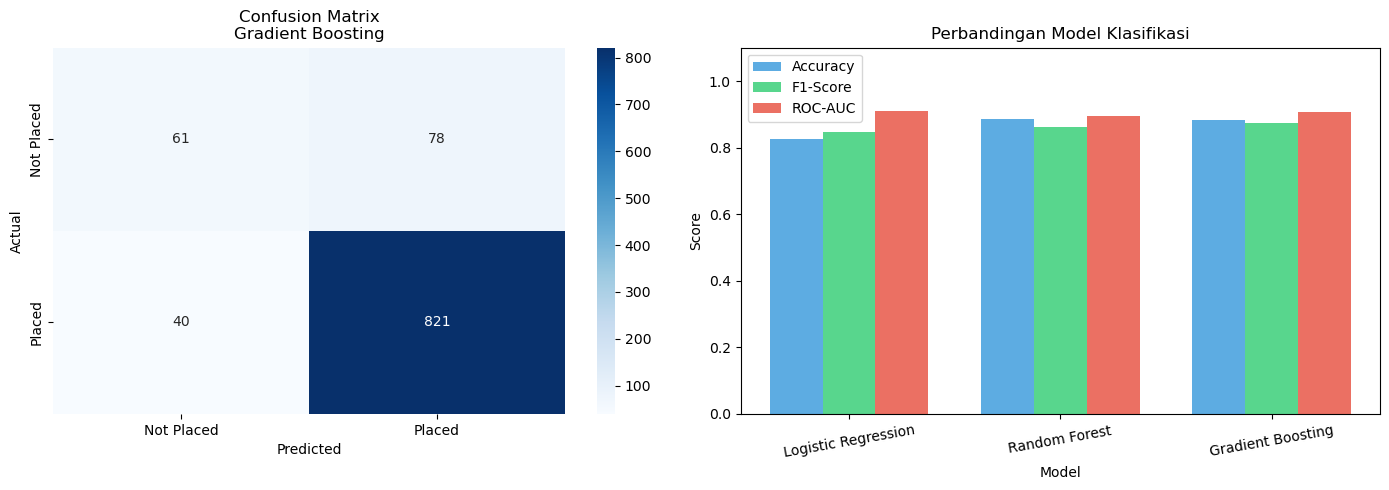


Best Classification Model: Gradient Boosting

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.60      0.44      0.51       139
      Placed       0.91      0.95      0.93       861

    accuracy                           0.88      1000
   macro avg       0.76      0.70      0.72      1000
weighted avg       0.87      0.88      0.87      1000



In [16]:
# Confusion Matrix for best classifier
best_clf_name = clf_df['F1-Score'].idxmax()
best_clf = clf_pipelines[best_clf_name]
y_pred_best = best_clf.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_clf_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Placed', 'Placed'],
            yticklabels=['Not Placed', 'Placed'])
axes[0].set_title(f'Confusion Matrix\n{best_clf_name}')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Model comparison
metrics = ['Accuracy', 'F1-Score', 'ROC-AUC']
x = np.arange(len(clf_df.index))
width = 0.25
bars_colors = ['#3498db', '#2ecc71', '#e74c3c']

for i, metric in enumerate(metrics):
    axes[1].bar(x + i*width, clf_df[metric], width, label=metric, color=bars_colors[i], alpha=0.8)

axes[1].set_xlabel('Model')
axes[1].set_ylabel('Score')
axes[1].set_title('Perbandingan Model Klasifikasi')
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(clf_df.index, rotation=10)
axes[1].legend()
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

print(f"\nBest Classification Model: {best_clf_name}")
print(f"\nClassification Report:")
print(classification_report(y_clf_test, y_pred_best, target_names=['Not Placed', 'Placed']))


### 6.2 Regression Task (Salary Prediction)

**Alasan pemilihan algoritma:**
- **Ridge Regression**: Regularized linear regression yang mengatasi multicollinearity, tepat sebagai baseline regresi.
- **Random Forest Regressor**: Non-parametric ensemble yang mampu menangkap hubungan non-linear antar fitur dan target.
- **Gradient Boosting Regressor**: State-of-the-art untuk tabular data, unggul dalam menangkap pola kompleks secara bertahap.


In [17]:
# Regression models
reg_models = {
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

reg_results = {}
reg_pipelines = {}

for name, model in reg_models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    pipeline.fit(X_train, y_reg_train)
    y_pred = pipeline.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred))
    mae = mean_absolute_error(y_reg_test, y_pred)
    r2 = r2_score(y_reg_test, y_pred)
    
    reg_results[name] = {'RMSE': rmse, 'MAE': mae, 'R²': r2}
    reg_pipelines[name] = pipeline
    
    print(f"  {name}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")
    print("\n")


  Ridge Regression
  RMSE : 6.2611
  MAE  : 4.7266
  R²   : -0.0062


  Random Forest
  RMSE : 6.3806
  MAE  : 4.9638
  R²   : -0.0450


  Gradient Boosting
  RMSE : 6.2752
  MAE  : 4.7492
  R²   : -0.0107




In [18]:
reg_df = pd.DataFrame(reg_results).T
print("\nREGRESSION RESULTS SUMMARY")
print(reg_df.round(4))


REGRESSION RESULTS SUMMARY
                     RMSE     MAE      R²
Ridge Regression   6.2611  4.7266 -0.0062
Random Forest      6.3806  4.9638 -0.0450
Gradient Boosting  6.2752  4.7492 -0.0107


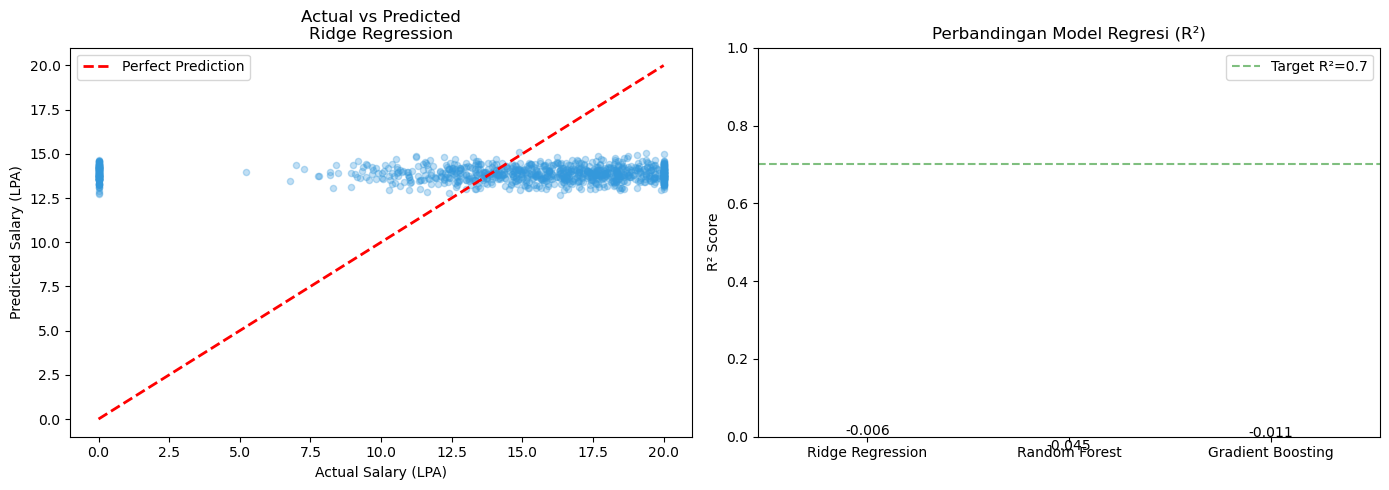


Best Regression Model: Ridge Regression


In [19]:
# Regression visualization
best_reg_name = reg_df['R²'].idxmax()
best_reg = reg_pipelines[best_reg_name]
y_pred_reg = best_reg.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_reg_test, y_pred_reg, alpha=0.3, color='#3498db', s=20)
min_val, max_val = min(y_reg_test.min(), y_pred_reg.min()), max(y_reg_test.max(), y_pred_reg.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Salary (LPA)')
axes[0].set_ylabel('Predicted Salary (LPA)')
axes[0].set_title(f'Actual vs Predicted\n{best_reg_name}')
axes[0].legend()

# Model comparison (R²)
colors = ['#e74c3c' if r < 0.5 else '#f39c12' if r < 0.7 else '#2ecc71' for r in reg_df['R²']]
axes[1].bar(reg_df.index, reg_df['R²'], color=colors, alpha=0.8, edgecolor='white')
axes[1].set_title('Perbandingan Model Regresi (R²)')
axes[1].set_ylabel('R² Score')
axes[1].set_ylim(0, 1)
axes[1].axhline(y=0.7, color='green', linestyle='--', alpha=0.5, label='Target R²=0.7')
axes[1].legend()
for i, (name, row) in enumerate(reg_df.iterrows()):
    axes[1].text(i, row['R²'] + 0.01, f"{row['R²']:.3f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nBest Regression Model: {best_reg_name}")


### 7. Interpretasi Hasil & Simpan Model Terbaik

**Interpretasi Metrik Evaluasi:**
- **Klasifikasi**: Model terbaik dipilih berdasarkan F1-Score (weighted) karena dataset imbalanced. ROC-AUC digunakan sebagai metrik tambahan untuk mengevaluasi kemampuan diskriminasi model.
- **Regresi**: Model terbaik dipilih berdasarkan R² tertinggi dan RMSE terendah. R² mengukur proporsi variansi yang dapat dijelaskan model.


In [ ]:
# Simpan model terbaik
os.makedirs('models', exist_ok=True)

# Save best classification model
with open('models/best_classifier.pkl', 'wb') as f:
    pickle.dump(best_clf, f)

# Save best regression model
with open('models/best_regressor.pkl', 'wb') as f:
    pickle.dump(best_reg, f)

# Save feature metadata
feature_metadata = {
    'numerical_features': NUMERICAL_FEATURES,
    'categorical_features': CATEGORICAL_FEATURES,
    'all_features': ALL_FEATURES
}
import json
with open('models/feature_metadata.json', 'w') as f:
    json.dump(feature_metadata, f)

print("Model berhasil disimpan!")
print(f"  models/best_classifier.pkl  : {best_clf_name}")
print(f"  models/best_regressor.pkl   : {best_reg_name}")
print(f"  models/feature_metadata.json")
print()
print(f"FINAL SUMMARY")
print(f"Best Classifier : {best_clf_name}")
print(f"  - Accuracy : {clf_results[best_clf_name]['Accuracy']:.4f}")
print(f"  - F1-Score : {clf_results[best_clf_name]['F1-Score']:.4f}")
print(f"  - ROC-AUC  : {clf_results[best_clf_name]['ROC-AUC']:.4f}")
print()
print(f"Best Regressor  : {best_reg_name}")
print(f"  - RMSE : {reg_results[best_reg_name]['RMSE']:.4f}")
print(f"  - MAE  : {reg_results[best_reg_name]['MAE']:.4f}")
print(f"  - R²   : {reg_results[best_reg_name]['R²']:.4f}")

Model berhasil disimpan!
  models/best_classifier.pkl  : Gradient Boosting
  models/best_regressor.pkl   : Ridge Regression
  models/feature_metadata.json

FINAL SUMMARY
Best Classifier : Gradient Boosting
  - Accuracy : 0.8820
  - F1-Score : 0.8739
  - ROC-AUC  : 0.9060

Best Regressor  : Ridge Regression
  - RMSE : 6.2611
  - MAE  : 4.7266
  - R²   : -0.0062
